In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from telco_churn.data_preparation import save_dataframe_to_csv
from telco_churn.plots import save_plot

In [2]:
TRAIN_TEST_SPLIT_PLOTS_PATH = '../reports/figures/train_test_split'
PROCESSED_DATA_PATH = '../data/processed'

## Split data into training and test sets

This notebook prepares the training and test datasets for further analysis and modeling.

Main steps:

1. Load `telco_customers_clean` and validate:

   - dimensions,
   - data types,
   - preview of the first five rows.

2. Analyze the target column `churn`:

   - confirm the SQL insight that the target distribution is imbalanced,
   - decide whether stratified sampling should be used during the train-test split.

3. Split the data into training and test sets:

   - use stratification to preserve the target distribution,
   - inspect the `churn` distribution after the split.

4. Save the training and test sets to CSV files.


In [3]:
# Load telco_customers_clean

df_clean = pd.read_csv('../data/processed/telco_customers_clean.csv')

In [4]:
# Dataset dimension

df_clean.shape

(7043, 21)

In [5]:
# Data types

df_clean.dtypes

customer_id           object
gender                object
senior_citizen         int64
partner               object
dependents            object
tenure                 int64
phone_service         object
multiple_lines        object
internet_service      object
online_security       object
online_backup         object
device_protection     object
tech_support          object
streaming_tv          object
streaming_movies      object
contract              object
paperless_billing     object
payment_method        object
monthly_charges      float64
total_charges        float64
churn                 object
dtype: object

In [6]:
# Dataset preview

df_clean.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
# Target 'churn' distribution before split

churn_distribution_count = df_clean['churn'].value_counts()
churn_distribution_pct = (df_clean['churn'].value_counts(normalize=True) * 100).round(2)
churn_distribution_summary = pd.concat([churn_distribution_count, churn_distribution_pct], axis=1, keys=['count', 'percentage'])

churn_distribution_summary

,count,percentage
churn,,
No,5174,73.46
Yes,1869,26.54


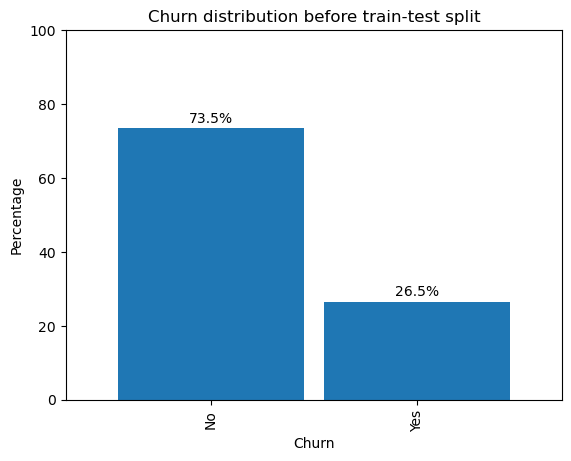

In [10]:
# Target 'churn' distribution bar plot

churn_bar_plot = churn_distribution_summary['percentage'].plot(kind='bar', width=0.9)

churn_bar_plot.bar_label(
    churn_bar_plot.containers[0],
    fmt='%.1f%%',
    padding=2
)

plt.ylim(0, 100)
plt.title('Churn distribution before train-test split')
plt.xlabel('Churn')
plt.ylabel('Percentage')

save_plot(
    path=TRAIN_TEST_SPLIT_PLOTS_PATH,
    file_name='churn_distribution_before_train_test_split'
)

plt.show()

## Summary

The `churn` target distribution is imbalanced. Customers who churned represent a much smaller group than customers who did not churn.

Because of that, I will use a stratified train-test split to preserve similar churn proportions in both the training and test datasets.

In [11]:
# Train-test split 

df_train, df_test = train_test_split(
    df_clean,
    test_size=0.2,
    random_state=42,
    stratify=df_clean['churn']
)

In [21]:
# Split size validation

split_size_validation = pd.DataFrame(
    {
        'dataset': ['df_train', 'df_test'],
        'rows': [df_train.shape[0], df_test.shape[0]],
        'pct': [round(df_train.shape[0]/df_clean.shape[0]*100, 1), round(df_test.shape[0]/df_clean.shape[0]*100, 1)]
    }
).set_index('dataset')

split_size_validation

,rows,pct
dataset,,
df_train,5634,80.0
df_test,1409,20.0


In [44]:
# Target 'churn' distribution after split

churn_train_distribution = (df_train['churn'].value_counts(normalize=True) * 100).round(2)
churn_test_distribution = (df_test['churn'].value_counts(normalize=True) * 100).round(2)

churn_distribution_validation = pd.concat(
    [churn_distribution_pct, churn_train_distribution, churn_test_distribution],
    axis=1,
    keys=['df_clean', 'df_train', 'df_test']
)

churn_distribution_validation

,telco_customers_clean,telco_customers_train,telco_customers_test
churn,,,
No,73.46,73.46,73.46
Yes,26.54,26.54,26.54


## Summary

The split size validation confirms that the dataset was split into approximately 80% training data and 20% test data. 

The target distribution validation confirms that stratification preserved similar `churn` proportions in both datasets.

In [22]:
# Save training set

train_set_path = save_dataframe_to_csv(
    df=df_train,
    path=PROCESSED_DATA_PATH,
    file_name='telco_customers_train'
)

train_set_path

'../data/processed\\telco_customers_train.csv'

In [23]:
# Save test set

test_set_path = save_dataframe_to_csv(
    df=df_test,
    path=PROCESSED_DATA_PATH,
    file_name='telco_customers_test'
)

test_set_path

'../data/processed\\telco_customers_test.csv'

## Summary

The dataset was split into training and test sets using a stratified train-test split.

Key outputs from this notebook:
- Bar plot with churn distribution saved to: `reports/figures/train_test_split/churn_pct_distribution.png`
- Train set saved to: `data/processed/telco_customers_train.csv`
- Test set saved to: `data/processed/telco_customers_test.csv`